# 实验4 机器学习之无监督学习

## 1. 梯度下降

梯度下降是一种经典而广泛应用的优化算法，主要用于最小化损失函数，通过逐步调整模型参数来提高预测性能。我们可以通过模拟梯度下降的过程来深入理解梯度下降。

（1）损失函数定义：我们选择一个二次函数作为损失函数，其形式为：

$$
L(x,y)=(x-2)^2+(y-3)^2
$$

该函数的最小值位于点 $(2, 3)$，这是我们希望通过梯度下降算法找到的目标。

In [1]:
def loss_function(x, y):
    return (x - 2)**2 + (y - 3)**2

（2）梯度计算：损失函数的梯度可以通过对函数求偏导得到，用于指导梯度下降过程中的更新方向。

$$
\frac{\partial L}{\partial x}=2(x-2), \quad \frac{\partial L}{\partial y}=2(y-3)
$$

In [2]:
# 定义损失函数的梯度  
def gradient(x, y):  
    grad_x = 2 * (x - 2)  
    grad_y = 2 * (y - 3)  
    return grad_x, grad_y  

（3）梯度下降算法定义
我们实现了梯度下降算法，步骤如下：
1. 初始化起始点和学习率。
2. 在每次迭代中，根据当前点的梯度更新坐标：

$$
x \leftarrow x-learning\_rate \times \frac{\partial L}{\partial x} \\
y \leftarrow y-learning\_rate \times \frac{\partial L}{\partial y}
$$

3. 记录每一步的坐标，以便后续可视化。

In [3]:
def gradient_descent(initial_point, learning_rate, num_iterations):  
    x, y = initial_point  
    trajectory = [(x, y)]  # 记录梯度下降过程中的点  
    for _ in range(num_iterations):  
        grad_x, grad_y = gradient(x, y)  
        x -= learning_rate * grad_x  
        y -= learning_rate * grad_y  
        trajectory.append((x, y))  
    return trajectory  

（4）梯度下降算法实现

In [4]:
initial_point = (0, 0)  # 起始点  
learning_rate = 0.1  # 学习率  
num_iterations = 50  # 迭代次数  
  
# 执行梯度下降  
trajectory = gradient_descent(initial_point, learning_rate, num_iterations)  

（5）可视化结果

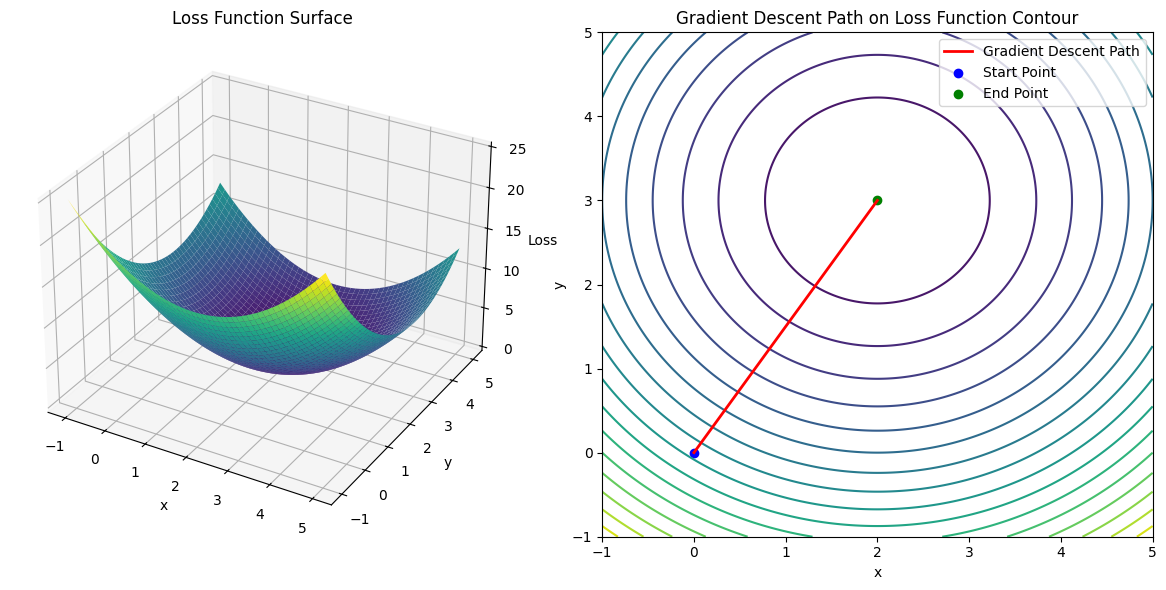

In [5]:
# 转换为numpy数组以便绘图
import numpy as np    
trajectory = np.array(trajectory)  

# 创建网格以绘制损失函数的曲面  
x_vals = np.linspace(-1, 5, 400)  
y_vals = np.linspace(-1, 5, 400)  
X, Y = np.meshgrid(x_vals, y_vals)  
Z = loss_function(X, Y)  

# 绘制损失函数的曲面
import matplotlib.pyplot as plt    
fig = plt.figure(figsize=(12, 6))  
  
ax1 = fig.add_subplot(121, projection='3d')  
ax1.plot_surface(X, Y, Z, cmap='viridis')  
ax1.set_title('Loss Function Surface')  
ax1.set_xlabel('x')  
ax1.set_ylabel('y')  
ax1.set_zlabel('Loss')  
  
# 绘制梯度下降的路径  
ax2 = fig.add_subplot(122)  
ax2.contour(X, Y, Z, levels=20, cmap='viridis')  
ax2.plot(trajectory[:, 0], trajectory[:, 1], 'r-', linewidth=2, label='Gradient Descent Path')  
ax2.scatter(trajectory[0, 0], trajectory[0, 1], color='blue', label='Start Point')  
ax2.scatter(trajectory[-1, 0], trajectory[-1, 1], color='green', label='End Point')  
ax2.set_title('Gradient Descent Path on Loss Function Contour')  
ax2.set_xlabel('x')  
ax2.set_ylabel('y')  
ax2.legend()  
  
# 显示图形  
plt.tight_layout()  
plt.show()

## 2.聚类  K-means

参考资料：https://scikit-learn.org/stable/modules/clustering.html#k-means

在鸢尾花例子中，聚类就像是在没有任何先验知识的情况下，仅仅根据花的特征（花萼和花瓣的长度和宽度）来将它们分类。

（1）数据加载：$X$包含特征数据（萼片和花瓣的长度和宽度），$y$包含真实的类别标签。

In [6]:
from sklearn import datasets

# 加载数据集
iris = datasets.load_iris()
X = iris.data
y = iris.target

（2）数据标准化：标准化的目的是将所有特征调整到相同的尺度，这对K-means算法很重要，因为它基于距离计算。

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

（3）模型创建与训练：指定簇的数量为3（因为鸢尾花有3个品种）。`random_state=42`确保结果可重复。

In [8]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

KMeans(n_clusters=3, random_state=42)

（4）模型预测：`predict`方法将每个数据点分配到最近的簇。`y_kmeans`包含每个数据点的簇标签。

In [9]:
y_kmeans = kmeans.predict(X_scaled)

（5）可视化：创建两个子图：左图显示原始数据的真实类别，右图显示K-means聚类的结果。我们只使用前两个特征（萼片长度和宽度）来创建2D散点图。

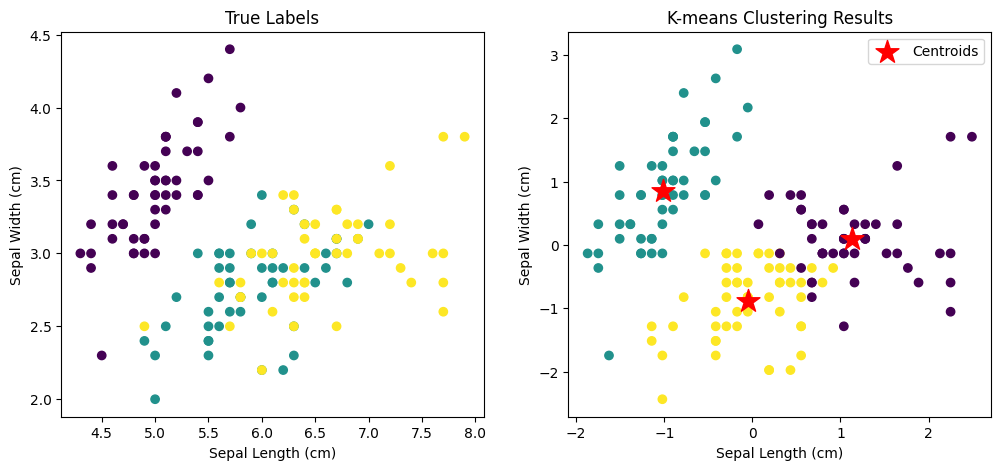

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 原始数据的真实类别
plt.subplot(121)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.title('True Labels')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')

# K-means聚类的结果
plt.subplot(122)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, cmap='viridis') # 这里应当绘制的散点图为标准化后的x
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=300, c='red', marker='*', label='Centroids')
plt.title('K-means Clustering Results')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend()
plt.show()

（6）模型评估：计算聚类的准确率。需要注意的是，K-means是一种无监督学习算法，通常不会用准确率来评估。但在这个例子中，由于我们知道真实的类别标签，所以可以用它来了解聚类效果。

In [11]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y, y_kmeans)
print(f"Clustering Accuracy: {accuracy:.2f}")

Clustering Accuracy: 0.09


（7）分析簇的组成

In [12]:
for i in range(3):
    cluster = np.where(y_kmeans == i)[0]
    print(f"\nComposition of Cluster {i}:")
    for iris_type in range(3):
        count = np.sum(y[cluster] == iris_type)
        print(f"  {iris.target_names[iris_type]}: {count}")


Composition of Cluster 0:
  setosa: 0
  versicolor: 11
  virginica: 36

Composition of Cluster 1:
  setosa: 50
  versicolor: 0
  virginica: 0

Composition of Cluster 2:
  setosa: 0
  versicolor: 39
  virginica: 14


## 3.降维

参考资料：https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn.decomposition.PCA

鸢尾花数据集有四个特征：花萼长度、花萼宽度、花瓣长度和花瓣宽度。我们可以想象三维空间，但四维空间超出了我们的直觉。主成分分析（Principal Component Analysis，PCA）要做的就是试图找到数据变化最大的方向（我们称之为主成分），然后用这些方向来表示数据。

（1）数据加载

In [13]:
from sklearn import datasets

# 加载数据集
iris = datasets.load_iris()
X = iris.data
y = iris.target

（2）数据标准化

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

（3）应用PCA：这里我们创建了一个PCA对象，并使用fit_transform方法对标准化后的数据进行转换。X_pca就是转换后的数据，其中每一列对应一个主成分。

In [15]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

（4）分析主成分：explained_variance_ratio_告诉我们每个主成分解释了多少比例的方差。通过查看 explained_variance_ratio_，可以决定选择多少个主成分以保留足够的方差（通常选择累积方差达到 90% 或 95%）。

In [16]:
explained_variance_ratio = pca.explained_variance_ratio_
print(f"Explained Variance Ratio: {explained_variance_ratio}")

Explained Variance Ratio: [0.72962445 0.22850762 0.03668922 0.00517871]


（5）分析主成分的组成：打印出每个主成分的特征向量,表示每个原始特征对主成分的贡献。然后计算并打印原始特征与主成分的相关性。这告诉我们每个主成分与原始特征的关系强度和方向。

In [17]:
print("主成分的特征向量:")
for i, component in enumerate(pca.components_):
    print(f"PC{i+1}: {component}")

print("\n原始特征与主成分的相关性:")
for i, component in enumerate(pca.components_):
    correlations = component * np.sqrt(pca.explained_variance_[i])
    print(f"PC{i+1}:")
    for j, corr in enumerate(correlations):
        print(f"  {iris.feature_names[j]}: {corr:.3f}")

主成分的特征向量:
PC1: [ 0.52106591 -0.26934744  0.5804131   0.56485654]
PC2: [0.37741762 0.92329566 0.02449161 0.06694199]
PC3: [-0.71956635  0.24438178  0.14212637  0.63427274]
PC4: [-0.26128628  0.12350962  0.80144925 -0.52359713]

原始特征与主成分的相关性:
PC1:
  sepal length (cm): 0.893
  sepal width (cm): -0.462
  petal length (cm): 0.995
  petal width (cm): 0.968
PC2:
  sepal length (cm): 0.362
  sepal width (cm): 0.886
  petal length (cm): 0.023
  petal width (cm): 0.064
PC3:
  sepal length (cm): -0.277
  sepal width (cm): 0.094
  petal length (cm): 0.055
  petal width (cm): 0.244
PC4:
  sepal length (cm): -0.038
  sepal width (cm): 0.018
  petal length (cm): 0.116
  petal width (cm): -0.076
